## ================
##  RANDOM FOREST
## ================

# 1. Random Forest from scratch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
# this depicts the node of a decision tree
class Node:
    def __init__(self,feature=None,threshold=None,left=None,right=None,value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        

In [34]:
def gini(y):
    """
    Calculate the gini for given labels
    """
    classes, count = np.unique(y,return_counts=True)
    prob = count / len(y)
    return 1-np.sum(prob**2)

def entropy(y):
    classes, count = np.unique(y, return_counts=True)
    prob = count / len(y)
    return -np.sum(prob * np.log2(prob+1e-9)) # adding small term 1e9 to avoid log 0


In [35]:
def best_split(X,y,criteria='gini', feature_indices=None):
    """
    For every feature in subset feature given, find the gain and for the best gain return the split.
    This is to build a node of the tree.
    Node level split
    """

    #if all the labels are same => Leaf Node = Base condition
    if len(np.unique(y))==1:
        return None

    N,d = X.shape

    best_gain = -1
    best_split_info = None

    #1st step = Parent's impurity
    parent_impurity = gini(y) if criteria=='gini' else entropy(y)

    # if subset is not mentioned, take all features
    if feature_indices==None:
        feature_indices = range(d)

    for feature in feature_indices: #for every column in given 
        threshold = np.unique(X[:,feature]) #every unique value can be threshold
        for th in threshold:
            left_mask = X[:,feature] <= th
            right_mask = X[:,feature] > th

            #if any split's right or left node is empty, then choose different split
            if np.sum(left_mask)==0 or np.sum(right_mask)==0:
                continue

            y_left = y[left_mask]
            y_right = y[right_mask]

            #now we've left and right labels, calculate gini and gain
            if criteria =='gini':
                left_imp = gini(y_left)
                right_imp = gini(y_right)
            else:
                left_imp = entropy(y_left)
                right_imp = entropy(y_right)
            
            #now find weigted impurity
            n_left = len(y_left)
            n_right = len(y_right)
            weighted_impurity = (n_left/N)*left_imp + (n_right/N)*right_imp

            #next step gain
            gain = parent_impurity - weighted_impurity

            #Find best split using gain
            if best_gain < gain:
                best_gain = gain
                best_split_info = {
                    'feature' : feature,
                    'threshold' :th,
                    'gain' : gain,
                    'left_indices' : left_mask,
                    'right_indices' : right_mask,
                }
    return best_split_info


In [36]:
def build_tree_rf(X,y,criteria = 'gini',max_depth = None, depth=0, n_features=None):
    """
    Recursively build tree with given max-depth and feature subset.
    n_features: number of features to sample at each split (sqrt(n) is typical).
    """

    # leaf node, value is being set to the label with larger count
    if len(np.unique(y)) == 1 or (max_depth is not None and depth >=max_depth):
        classes, count = np.unique(y, return_counts=True)
        return Node(value=classes[np.argmax(count)]) #argmax gives maximum value's index
    
    d = X.shape[1]
    if n_features == None:
        n_features = int(np.sqrt(d))# if not specified , find numbers by sqrt(default)
    
    #Randomly pick n_features without replacement => Rndomness in Random forest
    feature_indices = np.random.choice(d,size=n_features,replace=False)

    split_info = best_split(X,y,criteria,feature_indices)

    if split_info is None or split_info['gain'] <= 1e-9:
        classes, count = np.unique(y,return_counts=True)
        return Node(value= classes[np.argmax(count)])
    
    left_mask = split_info['left_indices']
    right_mask = split_info['right_indices']

    left_child = build_tree_rf(X[left_mask], y[left_mask],criteria,max_depth,depth+1,n_features)
    right_child = build_tree_rf(X[right_mask], y[right_mask],criteria, max_depth,depth+1,n_features)

    return Node(
        feature=split_info['feature'],
        threshold=split_info['threshold'],
        left = left_child,
        right = right_child
    )


In [37]:
def predict_tree(node,X):

    #found the leaf node, return the leaf value
    if node.value is not None:
        return np.full(X.shape[0],node.value)
    
    left_mask = X[:,node.feature] <= node.threshold
    right_mask = ~left_mask

    y_pred = np.zeros(X.shape[0],dtype=int)
    if np.any(left_mask):
        y_pred[left_mask] = predict_tree(node.left, X[left_mask])
    if np.any(right_mask):
        y_pred[right_mask] = predict_tree(node.right, X[right_mask])

    return y_pred


In [38]:
class Decision_Tree:
    def __init__(self,criteria='gini', max_depth=None,n_feature=None):
        self.criteria = criteria
        self.max_depth = max_depth
        self.n_feature = n_feature
        self.root = None

    def fit(self, X,y):
        self.root = build_tree_rf(X,y,self.criteria,self.max_depth,0,self.n_feature)

    def predict(self,X):
        return predict_tree(self.root,X)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [ ]:
from collections import Counter
class RandomForestClassifierScratch:
    def __init__(self,n_estimators=100, max_depth=None,criteria='gini',n_feature=None):
        self.n_estimators=n_estimators
        self.max_depth=max_depth
        self.criteria=criteria
        self.n_feature=n_feature
        self.trees = []
        self.feature_importances_= None

    def fit(self,X,y):
        N,d = X.shape
        self.trees = []

        if self.n_feature is None:
            self.n_feature = int(np.sqrt(d))
        
        for i in range(self.n_estimators):
            bootstrap_indices = np.random.choice(N,size=N,replace=True)
            X_bootstrap = X[bootstrap_indices]
            y_bootstrap = y[bootstrap_indices]

            #---------Train decision trees---------#
            tree = Decision_Tree(
                criteria=self.criteria,
                max_depth=self.max_depth,
                n_feature=self.n_feature
            )
            tree.fit(X_bootstrap,y_bootstrap)
            self.trees.append(tree)

        self.feature_importances_ = None
        print(f"Trained {self.n_estimators} trees with {self.n_feature} features per split.")

    def predict(self,X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])

        predictions = []
        for x in range(X.shape[0]):
            votes = tree_preds[:,x]
            most_common = Counter(votes).most_common(1)[0][0]
            predictions.append(most_common)
        return np.array(predictions)
    
    def score(self,X,y):
        y_pred = self.predict(X)
        return np.mean(y_pred==y)

In [ ]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Generate the moon data
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Single Decision Tree (max_depth=20) - Overfitted
single_tree = Decision_Tree(criteria='gini', max_depth=20, n_feature=None)  # None means use ALL features
single_tree.fit(X_train, y_train)
print(f"Single Tree (max_depth=20) - Train Acc: {single_tree.score(X_train, y_train):.3f}, Test Acc: {single_tree.score(X_test, y_test):.3f}")

# Random Forest (max_depth=20, n_estimators=50)
rf = RandomForestClassifierScratch(n_estimators=50, max_depth=20, criteria='gini')
rf.fit(X_train, y_train)
print(f"Random Forest (50 trees, depth=20) - Train Acc: {rf.score(X_train, y_train):.3f}, Test Acc: {rf.score(X_test, y_test):.3f}")

Single Tree (max_depth=20) - Train Acc: 1.000, Test Acc: 0.867
Trained 50 trees with 1 features per split.
Random Forest (50 trees, depth=20) - Train Acc: 0.995, Test Acc: 0.911


# 2. Sklearn Random Forest

In [63]:
#imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
#=============================#
# Loading the Titanic Dataset #
#=============================#
df = sns.load_dataset('titanic')

print(df.head(5))
print(df.info())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64

In [65]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [66]:
df_process = df[['survived','sex','age','sibsp','parch','fare','embarked','class','alone']].copy()

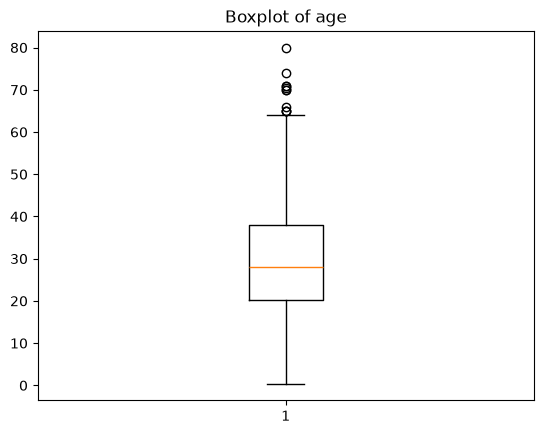

In [67]:
plt.boxplot(df_process["age"].dropna()) # a lot of NaN values, remove them to built a plot
plt.title("Boxplot of age")
plt.show()

In [68]:
#----Handle missing Values---------#
df_process['age'] = df_process['age'].fillna(df_process['age'].median()) 
# too many outlers,data is very skewed-> cann't fill it with mean, fill with meadian
df_process['embarked'] = df_process['embarked'].fillna(df_process['embarked'].mode()[0])
print(df_process.isnull().sum())

survived    0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
class       0
alone       0
dtype: int64


In [69]:
print(df_process.info())
print(df_process.head(10))


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   sex       891 non-null    str     
 2   age       891 non-null    float64 
 3   sibsp     891 non-null    int64   
 4   parch     891 non-null    int64   
 5   fare      891 non-null    float64 
 6   embarked  891 non-null    str     
 7   class     891 non-null    category
 8   alone     891 non-null    bool    
dtypes: bool(1), category(1), float64(2), int64(3), str(2)
memory usage: 50.7 KB
None
   survived     sex   age  sibsp  parch     fare embarked   class  alone
0         0    male  22.0      1      0   7.2500        S   Third  False
1         1  female  38.0      1      0  71.2833        C   First  False
2         1  female  26.0      0      0   7.9250        S   Third   True
3         1  female  35.0      1      0  53.1000        S   First  False
4         0    m

In [70]:
#-------Encode the categorical columns-------#
#columns = sex, embarked

#sex:  male=0, female=1
df_process['sex'] = df_process['sex'].map({'male':0, 'female':1})

#embarked: Label Encoding is fine for Trees bcz unlike linear regress, it doesn't learn the order
#but in random forest,it's still clearer to apply one hot encoding
df_process = pd.get_dummies(df_process, columns=['embarked'], prefix='emb',drop_first=False)

#class: First, Second, Third
df_process = pd.get_dummies(df_process, columns=['class'], prefix='class',drop_first=False)


In [71]:
#----Separate Features(X) and target(y)-----#
X = df_process.drop('survived',axis=1).values #drop the survived column, and .values convert DataFrame into nparray
y = df_process['survived'].values

In [73]:
print(X.shape)

(891, 12)


In [74]:
#================================#
# Manual 5-Fold Cross-Validation #
#================================#

In [75]:
kf = KFold(n_splits=5,shuffle=True, random_state=42)

fold_number=1
fold_scores = []

for train_index, test_index in kf.split(X):
    print(f"\n--- Fold {fold_number} ---")

    #split the data based on indices
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    #Create and train the model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    #predict model on test data
    y_pred = model.predict(X_test)

    #Calculate accuracy for this fold
    acc = accuracy_score(y_test,y_pred)
    fold_scores.append(acc)

    print(f"\nValidation score at fold {fold_number} = {acc:.4f}")

    fold_number +=1

#Average accuracy of all the folds
avg_acc = np.mean(fold_scores)
print(f"\nAverage Score : {avg_acc}")
print(f"Standard Deviation : {np.std(fold_scores)}")



--- Fold 1 ---

Validation score at fold 1 = 0.8156

--- Fold 2 ---

Validation score at fold 2 = 0.8202

--- Fold 3 ---

Validation score at fold 3 = 0.8483

--- Fold 4 ---

Validation score at fold 4 = 0.8034

--- Fold 5 ---

Validation score at fold 5 = 0.8258

Average Score : 0.8226790534178645
Standard Deviation : 0.014802275729764934


In [76]:
#===================================#
# Train Final model on all the data #
#===================================#

In [82]:
#Final model
final_model = RandomForestClassifier(n_estimators=50, random_state=42)
final_model.fit(X,y)

#Get feature importance
feature_names = df_process.drop('survived',axis=1).columns.to_list()
importances = final_model.feature_importances_

#Lowest importance feature
min_index = np.argmin(importances)
min_feature = feature_names[min_index]
min_importance = importances[min_index]

print("Feature Importances:")
for name,imp in zip(feature_names, importances):
    print(f"{name} : {imp:.4f}")
print(f"\nLowest importance fetaure : {min_feature} with {min_importance:.4f}")

#Drop the lowest importance feature
X_dropped = np.delete(X,min_index,axis=1)

#With 5-Fold train the model on new data
kf_new = KFold(n_splits=5, shuffle=True, random_state=42)
drop_scores = []

for train_idx, test_idx in kf_new.split(X_dropped):
    X_train_d,X_test_d = X_dropped[train_idx],X_dropped[test_idx]
    y_train_d,y_test_d = y[train_idx], y[test_idx]

    model_d = RandomForestClassifier(n_estimators=20, random_state=42)
    model_d.fit(X_train_d,y_train_d)

    acc_d = accuracy_score(y_test_d, model_d.predict(X_test_d))

    drop_scores.append(acc_d)

avg_drop_score = np.mean(drop_scores)
print("====================================================================")
print(f"5-Fold Accuracy score without {min_feature} : {avg_drop_score:.4f}")
print(f"Original Accuracy with all the features : {avg_acc:.4f}")
print(f"Difference : {avg_acc - avg_drop_score:.4f}")


Feature Importances:
sex : 0.2530
age : 0.2624
sibsp : 0.0395
parch : 0.0350
fare : 0.2614
alone : 0.0151
emb_C : 0.0114
emb_Q : 0.0083
emb_S : 0.0164
class_First : 0.0297
class_Second : 0.0167
class_Third : 0.0509

Lowest importance fetaure : emb_Q with 0.0083
5-Fold Accuracy score without emb_Q : 0.8002
Original Accuracy with all the features : 0.8227
Difference : 0.0224
